# Foundations of Machine learning

Problem Set 1

Emily Fu

## 1. Load the iris data set, using the seaborn package:

In [ ]:
# importing packages and methods

# for the dataset
from sklearn import datasets

# splitting data, cross-validation, and hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, validation_curve, cross_val_score

# classification algorithm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# accuracy and stuff
from sklearn import metrics

# plotting 
import matplotlib.pyplot as plt
from seaborn import heatmap

In [24]:
# setting parameters

# set seed
import numpy as np
seed = np.random.seed(420)

# number of folds for cross-validation
k_folds = 5

# how many neighbours for KNN
n_neighbours = 3

In [37]:
# load data
iris = datasets.load_iris()
X = iris.data
y = iris.target

## 2. Split the Iris dataset into training and testing sets using train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

## 3. Train a LogisticRegression model on the training set.

In [47]:
# training model (using the default parameters)
model = LogisticRegression(random_state=seed)

# fit the model with data
model.fit(X_train, y_train)

# predicted values
y_pred = model.predict(X_test)

## 4. Evaluate the model’s performance on the test set using accuracy score.

The accuracy is the proportion of all classifications that were correctly classified (flower name is assigned correctly). This model has an accuracy of 0.93, so 93% of the flowers in the test set are classified correctly.

In [48]:
# accuracy of the model
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.93


## 5. Perform 5-fold cross-validation on the Iris dataset using cross_val_score with a KNeigh-borsClassifier, using 3 nearest neighbors.

In [ ]:
# training model
# specified number of observations closest to a given data point
knn_model = KNeighborsClassifier(n_neighbors=n_neighbours)

# the training set is split into k (k_folds) smaller sets 
# using k-1 of the folds as training data to train the model, and
# the remaining fold is used as a test set to evaluate the model
cv_scores = cross_val_score(knn_model, X, y, cv=k_folds)

# print the cross-validation scores
print(f'Cross-validation scores: {cv_scores}')
print(f'Mean cross-validation score: {cv_scores.mean():.2f}')

Cross-validation scores: [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Mean cross-validation score: 0.97


## 6. Use GridSearchCV to find the best hyperparameter (number of nearest neighbors) for this classifier, using only the training data.

Same thing as in Stein’s Unbiased Risk Estimate: we're trying to pick the hyper-parameter based on performance

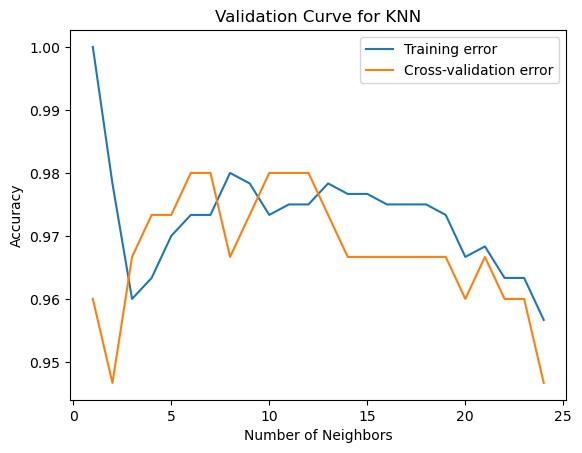

In [68]:
# plot validation curve for KNN with different number of neighbors
# define the parameter grid
param_grid = {'n_neighbors': np.arange(1, 25)}

train_scores, test_scores = validation_curve(knn_model, X, y,
                                             param_name='n_neighbors', param_range=param_grid['n_neighbors'],
                                             cv=k_folds, scoring='accuracy')
# calculate mean and standard deviation of training and test scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# plot the validation curve
plt.figure()
plt.plot(param_grid['n_neighbors'], train_scores_mean, label='Training error')
plt.plot(param_grid['n_neighbors'], test_scores_mean, label='Cross-validation error')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.title('Validation Curve for KNN')
plt.legend()
plt.show()

In [ ]:
# use grid search to find the best number of neighbors for KNN
grid = GridSearchCV(knn_model, param_grid, cv=k_folds)
# fit the grid search
grid.fit(X, y)

# print the best parameters
print(grid.best_params_)

{'n_neighbors': np.int64(6)}


In [70]:
grid.best_score_

np.float64(0.9800000000000001)

## 7. Compute and plot the confusion matrix for the optimal classifier that your found, using the test data.

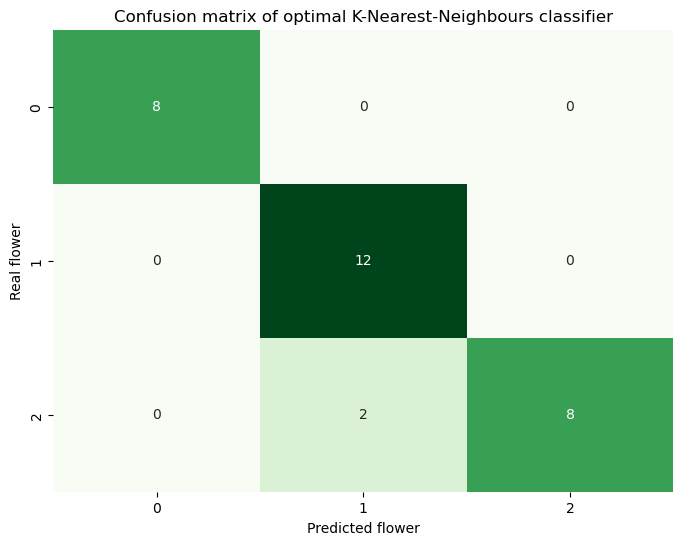

In [76]:
# plot confusing matrix for the grid search best model using seaborn heatmap
# get the best model from grid search
model_best = grid.best_estimator_
# predict the labels for the test set
y_pred_best = model_best.predict(X_test)
# compute the confusion matrix
confusionmatrix = metrics.confusion_matrix(y_test, y_pred_best)
# plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
heatmap(confusionmatrix, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.xlabel('Predicted flower')
plt.ylabel('Real flower')
plt.title('Confusion matrix of optimal K-Nearest-Neighbours classifier')
plt.show()
